# DreamGuard — Study Analysis

**Setup:**
```bash
cd scripts
uv sync                   # install dependencies
```

**Pull data from Quest:**
```bash
adb pull /sdcard/Android/data/com.DefaultCompany.DreamGuard/files/experiments ../data
```

Expected layout:
```
data/
  study_1/  study.csv  rooms.csv  collection.csv  position.csv  headset.csv  r_controller.csv  l_controller.csv
  study_2/  ...
```

In [1]:
from pathlib import Path
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from PIL import Image
from IPython.display import display, Image as IPyImage

warnings.filterwarnings('ignore')
%matplotlib inline

SCRIPTS_DIR = Path('.').resolve()
DATA_DIR    = SCRIPTS_DIR.parent / 'data'

_img_candidates = [
    SCRIPTS_DIR.parent / 'data' / 'dungeon' / 'DungeonTopDown.png',
    SCRIPTS_DIR.parent / 'docs' / 'assets' / 'DungeonTopDown.png',
]
DUNGEON_IMG = next((p for p in _img_candidates if p.exists()), _img_candidates[-1])

# JSON may live in data/dungeon/ even when the image is in docs/assets/
_json_candidates = [
    SCRIPTS_DIR.parent / 'data' / 'dungeon' / 'DungeonTopDown.json',
    DUNGEON_IMG.with_suffix('.json'),
]
DUNGEON_JSON = next((p for p in _json_candidates if p.exists()), _json_candidates[-1])

assert DATA_DIR.exists(), f'data/ not found at {DATA_DIR}'
sessions = sorted(DATA_DIR.glob('study_*'), key=lambda p: int(p.name.split('_')[1]))
assert sessions, 'No study_* folders found'
print(f'Found {len(sessions)} session(s): {[s.name for s in sessions]}')
print(f'Dungeon image : {DUNGEON_IMG}  (exists={DUNGEON_IMG.exists()})')
print(f'Dungeon JSON  : {DUNGEON_JSON} (exists={DUNGEON_JSON.exists()})')


Found 1 session(s): ['study_0']
Dungeon image : F:\Unity\Projects\DreamGuard\docs\assets\DungeonTopDown.png  (exists=True)
Dungeon JSON  : F:\Unity\Projects\DreamGuard\data\dungeon\DungeonTopDown.json (exists=True)


## Load all sessions

In [2]:
def read_csv(session_dir: Path, name: str) -> pd.DataFrame:
    p = session_dir / name
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    if 'timestamp_iso' in df.columns:
        df['timestamp_iso'] = pd.to_datetime(df['timestamp_iso'])
    return df

def extract(detail: str, key: str) -> str:
    if pd.isna(detail):
        return ''
    for part in str(detail).split():
        if part.startswith(f'{key}='):
            return part[len(key)+1:]
    return ''

def nearest_pos(pos_df: pd.DataFrame, ts: pd.Timestamp):
    """Return the (x, z) position sample closest to timestamp ts."""
    if pos_df.empty:
        return None, None
    idx = (pos_df['timestamp_iso'] - ts).abs().idxmin()
    r = pos_df.loc[idx]
    return r['x'], r['z']

data = {}
for sd in sessions:
    data[sd.name] = {
        'dir':        sd,
        'study':      read_csv(sd, 'study.csv'),
        'rooms':      read_csv(sd, 'rooms.csv'),
        'collection': read_csv(sd, 'collection.csv'),
        'position':   read_csv(sd, 'position.csv'),
        'headset':    read_csv(sd, 'headset.csv'),
        'r_ctrl':     read_csv(sd, 'r_controller.csv'),
        'l_ctrl':     read_csv(sd, 'l_controller.csv'),
    }

print('Loaded.')

Loaded.


## Session Overview

In [3]:
rows = []
for name, d in data.items():
    s = d['study']
    if s.empty:
        continue
    t0 = s[s.event_type == 'SESSION_START']['timestamp_iso']
    t1 = s[s.event_type == 'SESSION_END']['timestamp_iso']
    t0 = t0.iloc[0] if not t0.empty else s.timestamp_iso.min()
    t1 = t1.iloc[0] if not t1.empty else s.timestamp_iso.max()
    rows.append({
        'session':         name,
        'participant':     s['participant_id'].dropna().iloc[0],
        'condition':       s['condition'].dropna().iloc[0],
        'duration_min':    round((t1 - t0).total_seconds() / 60, 1),
        'rooms_complete':  (s.event_type == 'ROOM_COMPLETE').sum(),
        'orbs_collected':  len(d['collection']),
        'triggers':        (s.event_type == 'TRIGGER').sum(),
        'intrusions':      (s.event_type == 'INTRUSION_MARK').sum(),
        'false_positives': (s.event_type == 'FALSE_POSITIVE').sum(),
        'pos_samples':     len(d['position']),
    })

overview = pd.DataFrame(rows)
display(overview)

,session,participant,condition,duration_min,rooms_complete,orbs_collected,triggers,intrusions,false_positives,pos_samples
0,study_0,P00,baseline,4.6,4,16,5,0,0,12411


## Trigger Latency

,session,participant,condition,room_id,latency_s,technique
0,study_0,P00,baseline,room_1,0.002,default
1,study_0,P00,baseline,room_2,0.002,default
2,study_0,P00,baseline,room_3,0.052,default
3,study_0,P00,baseline,room_4,0.004,default


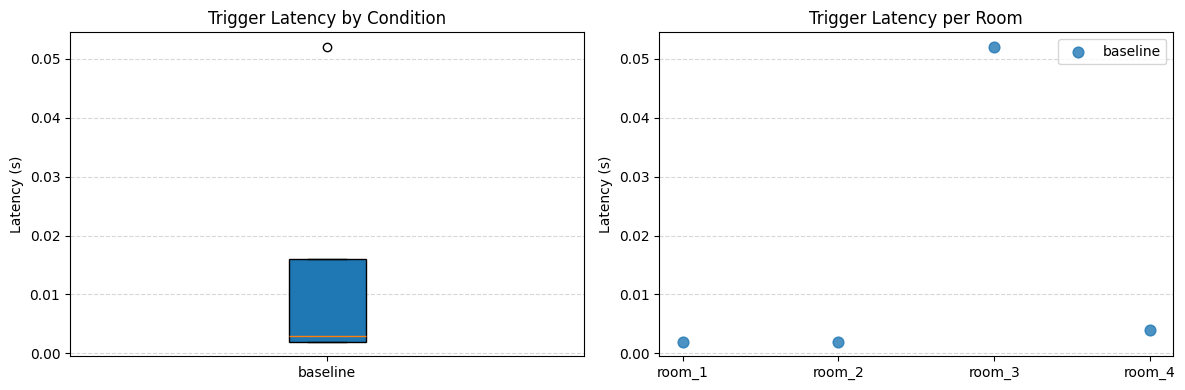

In [4]:
latency_rows = []
for name, d in data.items():
    s = d['study']
    if s.empty:
        continue
    halfways = s[s.event_type == 'ROOM_HALFWAY'].copy()
    triggers  = s[s.event_type == 'TRIGGER'].copy()
    halfways['room_id'] = halfways['detail'].apply(lambda x: extract(x, 'room_id'))
    pid  = s['participant_id'].dropna().iloc[0]
    cond = s['condition'].dropna().iloc[0]
    for _, hw in halfways.iterrows():
        later = triggers[triggers.timestamp_iso > hw.timestamp_iso]
        if later.empty:
            continue
        trig = later.iloc[0]
        latency_rows.append({
            'session': name, 'participant': pid, 'condition': cond,
            'room_id': hw['room_id'],
            'latency_s': (trig.timestamp_iso - hw.timestamp_iso).total_seconds(),
            'technique': extract(trig['detail'], 'technique'),
        })

latency_df = pd.DataFrame(latency_rows)

if latency_df.empty:
    print('No trigger latency data yet.')
else:
    display(latency_df)
    conditions = latency_df['condition'].unique()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    groups = [latency_df[latency_df.condition == c]['latency_s'].values for c in conditions]
    axes[0].boxplot(groups, labels=conditions, patch_artist=True)
    axes[0].set_ylabel('Latency (s)')
    axes[0].set_title('Trigger Latency by Condition')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    for c in conditions:
        sub = latency_df[latency_df.condition == c]
        axes[1].scatter(sub['room_id'], sub['latency_s'], label=c, alpha=0.8, s=60)
    axes[1].set_ylabel('Latency (s)')
    axes[1].set_title('Trigger Latency per Room')
    axes[1].legend()
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(DATA_DIR / 'latency.png', dpi=150, bbox_inches='tight')
    plt.show()

## Room Durations

,session,participant,condition,room_id,duration_s
0,study_0,P00,baseline,room_1,61.126
1,study_0,P00,baseline,room_2,53.856
2,study_0,P00,baseline,room_3,68.936
3,study_0,P00,baseline,room_4,65.613


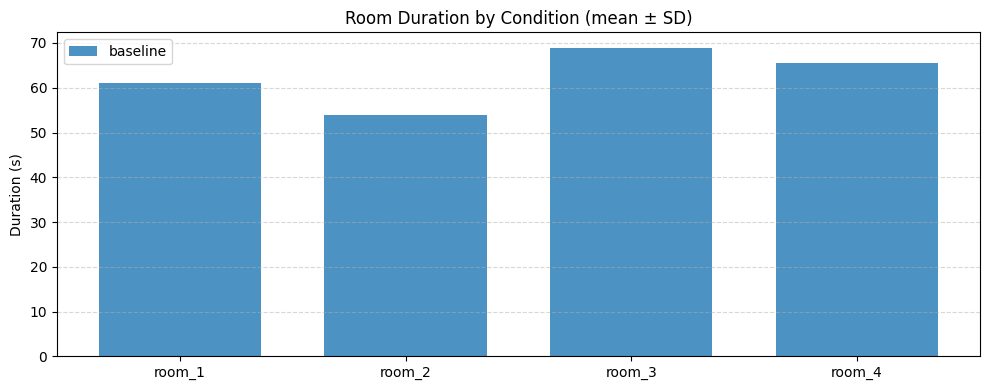

In [5]:
dur_rows = []
for name, d in data.items():
    rooms = d['rooms']
    s     = d['study']
    if rooms.empty or s.empty:
        continue
    cond = s['condition'].dropna().iloc[0]
    pid  = s['participant_id'].dropna().iloc[0]
    enters = rooms[rooms.event == 'ENTER'].set_index('room_id')['timestamp_iso']
    exits  = rooms[rooms.event == 'EXIT'].set_index('room_id')['timestamp_iso']
    for room_id in enters.index.intersection(exits.index):
        dur_rows.append({
            'session': name, 'participant': pid, 'condition': cond,
            'room_id': room_id,
            'duration_s': (exits[room_id] - enters[room_id]).total_seconds(),
        })

dur_df = pd.DataFrame(dur_rows)

if dur_df.empty:
    print('No room duration data yet.')
else:
    display(dur_df)
    conditions = dur_df['condition'].unique()
    room_ids   = sorted(dur_df['room_id'].unique())
    x = np.arange(len(room_ids))
    w = 0.8 / max(len(conditions), 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    for i, cond in enumerate(conditions):
        sub   = dur_df[dur_df.condition == cond].groupby('room_id')['duration_s']
        means = [sub.mean().get(r, 0) for r in room_ids]
        stds  = [sub.std().get(r, 0)  for r in room_ids]
        ax.bar(x + i*w, means, w*0.9, yerr=stds, label=cond, capsize=4, alpha=0.8)
    ax.set_xticks(x + w*(len(conditions)-1)/2)
    ax.set_xticklabels(room_ids)
    ax.set_ylabel('Duration (s)')
    ax.set_title('Room Duration by Condition (mean ± SD)')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(DATA_DIR / 'room_durations.png', dpi=150, bbox_inches='tight')
    plt.show()

## Minimap Setup

World-space bounds are auto-derived from position data (Unity X = horizontal, Z = depth / up in top-down view).

Each room panel uses **square display bounds** (`ROOM_DISPLAY`) centered on the room's trajectory centroid, with a uniform half-size across all rooms. This prevents squishing regardless of per-room Z extent variation. `ROOM_BOUNDS` is kept unchanged for data filtering.

- `_BG_ZOOM_FRAC` — extra fractional padding beyond the max trajectory extent (default 0.05 = 5%, shows outer walls)

If room_4's background is cut off on the right, the dungeon screenshot doesn't cover Z > 73.75 — re-run **Tools > DreamGuard > Dungeon Top-Down Screenshot** in Unity to update it.

In [6]:
dungeon_img = None
if DUNGEON_IMG.exists():
    dungeon_img = Image.open(DUNGEON_IMG).convert('RGBA')
    print(f'Dungeon image: {dungeon_img.size[0]}×{dungeon_img.size[1]} px  ({DUNGEON_IMG})')
else:
    print(f'WARNING: Dungeon image not found at {DUNGEON_IMG}')

# ── World bounds from DungeonTopDown.json ────────────────────────────────────
if DUNGEON_JSON.exists():
    cam = json.loads(DUNGEON_JSON.read_text())
    ortho  = cam['ortho_size']
    aspect = cam['aspect']
    WORLD_XMIN = cam['center_x'] - ortho * aspect
    WORLD_XMAX = cam['center_x'] + ortho * aspect
    WORLD_ZMIN = cam['center_z'] - ortho
    WORLD_ZMAX = cam['center_z'] + ortho
    print(f'Camera: center=({cam["center_x"]:.2f}, {cam["center_z"]:.2f})  orthoSize={ortho:.2f}  aspect={aspect}')
else:
    print('WARNING: DungeonTopDown.json not found — re-run Tools > DreamGuard > Dungeon Top-Down Screenshot.')
    all_pos = pd.concat([d['position'] for d in data.values() if not d['position'].empty], ignore_index=True)
    if all_pos.empty:
        WORLD_XMIN, WORLD_XMAX = -10.0, 10.0
        WORLD_ZMIN, WORLD_ZMAX = -5.0, 40.0
    else:
        pad_x = max((all_pos['x'].max() - all_pos['x'].min()) * 0.05, 1.0)
        pad_z = max((all_pos['z'].max() - all_pos['z'].min()) * 0.05, 1.0)
        WORLD_XMIN = all_pos['x'].min() - pad_x; WORLD_XMAX = all_pos['x'].max() + pad_x
        WORLD_ZMIN = all_pos['z'].min() - pad_z; WORLD_ZMAX = all_pos['z'].max() + pad_z

print(f'World bounds — X: [{WORLD_XMIN:.2f}, {WORLD_XMAX:.2f}]  Z: [{WORLD_ZMIN:.2f}, {WORLD_ZMAX:.2f}]')

# ── Per-room bounds (used for event filtering) ────────────────────────────────
def _compute_room_bounds_raw(data: dict) -> dict:
    room_pos: dict[str, list] = {}
    for d in data.values():
        pos   = d['position']
        rooms = d['rooms']
        if pos.empty or rooms.empty:
            continue
        enters = rooms[rooms.event == 'ENTER'].set_index('room_id')['timestamp_iso']
        exits  = rooms[rooms.event == 'EXIT'].set_index('room_id')['timestamp_iso']
        for rid in enters.index.intersection(exits.index):
            mask = (pos.timestamp_iso >= enters[rid]) & (pos.timestamp_iso <= exits[rid])
            sub  = pos[mask]
            if not sub.empty:
                room_pos.setdefault(rid, []).append(sub)
    raw = {}
    for rid, dfs in room_pos.items():
        all_df = pd.concat(dfs)
        raw[rid] = dict(xmin=float(all_df.x.min()), xmax=float(all_df.x.max()),
                        zmin=float(all_df.z.min()), zmax=float(all_df.z.max()))
    return raw

_raw = _compute_room_bounds_raw(data)
SORTED_ROOMS = sorted(_raw, key=lambda r: _raw[r]['zmin'])
print(f'Room bounds: {len(SORTED_ROOMS)} rooms' if _raw else 'No per-room position data.')

# ── Tight display bounds from position data ───────────────────────────────────
_all_pos_df = pd.concat([d['position'] for d in data.values() if not d['position'].empty], ignore_index=True)
_DISP_PAD = 2.0  # world-unit padding around traversed area
DISP_XMIN = _all_pos_df['x'].min() - _DISP_PAD
DISP_XMAX = _all_pos_df['x'].max() + _DISP_PAD
DISP_ZMIN = _all_pos_df['z'].min() - _DISP_PAD
DISP_ZMAX = _all_pos_df['z'].max() + _DISP_PAD
print(f'Display bounds — X: [{DISP_XMIN:.2f}, {DISP_XMAX:.2f}]  Z: [{DISP_ZMIN:.2f}, {DISP_ZMAX:.2f}]')

# ── Dungeon image array (kept at full world extent for imshow mapping) ────────
_dungeon_arr = np.array(dungeon_img) if dungeon_img is not None else None

# Make black background transparent
if _dungeon_arr is not None:
    dark_mask = _dungeon_arr[..., :3].max(axis=2) < 20
    _dungeon_arr = _dungeon_arr.copy()
    _dungeon_arr[dark_mask, 3] = 0
    _bg_img = np.rot90(_dungeon_arr, k=-1)
    print(f'Image prepared: {_dungeon_arr.shape[1]}×{_dungeon_arr.shape[0]} px (black bg → transparent)')
else:
    _bg_img = None

# ── Figure / drawing helpers ──────────────────────────────────────────────────
def make_full_fig():
    """Figure sized to the tight display bounds (Z horizontal, X vertical)."""
    z_span = DISP_ZMAX - DISP_ZMIN
    x_span = DISP_XMAX - DISP_XMIN
    base = 9
    scale = base / max(z_span, x_span)
    fig, ax = plt.subplots(figsize=(max(z_span * scale, 3), max(x_span * scale, 3)),
                           layout='constrained')
    return fig, ax

def draw_bg_full(ax):
    """Draw the dungeon background clipped to the tight display bounds."""
    if _bg_img is not None:
        ax.imshow(_bg_img,
                  extent=[WORLD_ZMIN, WORLD_ZMAX, WORLD_XMIN, WORLD_XMAX],
                  origin='lower', zorder=0)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(DISP_ZMIN, DISP_ZMAX)
    ax.set_ylim(DISP_XMIN, DISP_XMAX)
    ax.set_xlabel('Z')
    ax.set_ylabel('X')

def make_heatmap_full(dfs, resolution=300):
    xs = np.concatenate([df['x'].values for df in dfs])
    zs = np.concatenate([df['z'].values for df in dfs])
    hm, _, _ = np.histogram2d(xs, zs, bins=resolution,
                               range=[[WORLD_XMIN, WORLD_XMAX], [WORLD_ZMIN, WORLD_ZMAX]])
    return hm

def overlay_heatmap_full(ax, hm, alpha=0.6):
    masked = np.ma.masked_where(hm == 0, hm)
    cmap   = plt.cm.hot_r.copy(); cmap.set_bad(alpha=0.0)
    vmax   = max(hm.max(), 1)
    norm   = mcolors.PowerNorm(gamma=0.4, vmin=1, vmax=vmax)
    ax.imshow(masked, extent=[WORLD_ZMIN, WORLD_ZMAX, WORLD_XMIN, WORLD_XMAX],
              origin='lower', cmap=cmap, alpha=alpha, zorder=1, norm=norm)
    return cmap, norm

EVENT_STYLES = {
    'ROOM_ENTER':       dict(marker='o',  color='#2196F3', ms=10, zorder=4, label='Room enter'),
    'ROOM_HALFWAY':     dict(marker='v',  color='#9C27B0', ms=10, zorder=4, label='Room halfway'),
    'ROOM_COMPLETE':    dict(marker='s',  color='#1565C0', ms=10, zorder=4, label='Room complete'),
    'INTRUSION_MARK':   dict(marker='^',  color='#F44336', ms=12, zorder=5, label='Intrusion'),
    'TRIGGER':          dict(marker='*',  color='#E91E63', ms=15, zorder=5, label='Trigger'),
    'FALSE_POSITIVE':   dict(marker='x',  color='#FF5722', ms=12, zorder=5, label='False positive'),
    'CONFEDERATE_EXIT': dict(marker='D',  color='#795548', ms=9,  zorder=4, label='Confederate exit'),
}

def legend_handle(etype: str) -> Line2D:
    st = EVENT_STYLES[etype]
    return Line2D([0],[0], marker=st['marker'], color='w',
                  markerfacecolor=st['color'], markersize=8,
                  label=st['label'], markeredgecolor='black', markeredgewidth=0.5)

print('Minimap setup complete.')


Dungeon image: 2048×2048 px  (F:\Unity\Projects\DreamGuard\docs\assets\DungeonTopDown.png)
Camera: center=(0.25, 23.25)  orthoSize=50.50  aspect=1
World bounds — X: [-50.25, 50.75]  Z: [-27.25, 73.75]
Room bounds: 4 rooms
Display bounds — X: [-12.62, 12.97]  Z: [-25.47, 71.35]
Image prepared: 2048×2048 px (black bg → transparent)
Minimap setup complete.


## Minimap — Player Trajectory per Session

Path colour = time (purple → yellow). Symbols mark key events at the player's nearest recorded position.

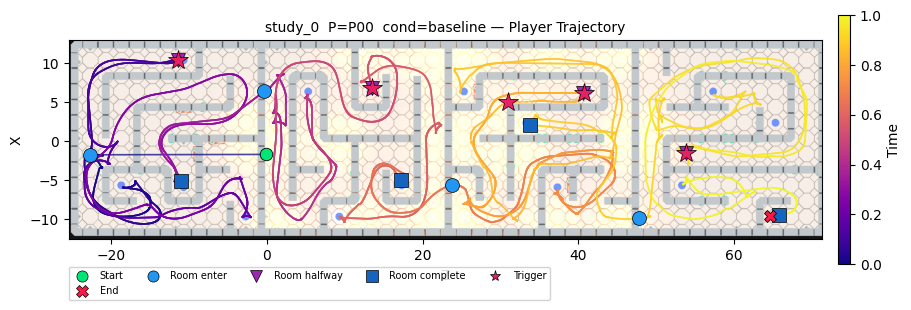

In [7]:
with_pos = [(n, d) for n, d in data.items() if not d['position'].empty]
if not with_pos:
    print('No position data.')
else:
    for name, d in with_pos:
        fig, ax = make_full_fig()
        draw_bg_full(ax)

        study = d['study']
        pos   = d['position']
        xs, zs = pos['x'].values, pos['z'].values
        t = np.linspace(0, 1, len(xs))

        for j in range(len(xs) - 1):
            ax.plot(zs[j:j+2], xs[j:j+2],
                    color=cm.plasma(t[j]), lw=1.2, alpha=0.75, zorder=2)
        if len(xs):
            ax.plot(zs[0],  xs[0],  'o', color='#00E676', ms=9, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.6, linestyle='None')
            ax.plot(zs[-1], xs[-1], 'X', color='#FF1744', ms=9, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.6, linestyle='None')

        legend_pool = {}
        for etype, st in EVENT_STYLES.items():
            for _, ev in study[study.event_type == etype].iterrows():
                px, pz = nearest_pos(pos, ev.timestamp_iso)
                if px is None:
                    continue
                ax.plot(pz, px, marker=st['marker'], color=st['color'],
                        markersize=st['ms'], zorder=st['zorder'],
                        markeredgecolor='black', markeredgewidth=0.5, linestyle='None')
                legend_pool.setdefault(etype, legend_handle(etype))

        sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 1))
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label='Time', fraction=0.04, pad=0.02)

        extra = [
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#00E676',
                   markersize=8, label='Start', markeredgecolor='black', markeredgewidth=0.5),
            Line2D([0],[0], marker='X', color='w', markerfacecolor='#FF1744',
                   markersize=8, label='End',   markeredgecolor='black', markeredgewidth=0.5),
        ]
        all_handles = extra + list(legend_pool.values())
        # Legend outside axes, below the plot
        ax.legend(handles=all_handles,
                  loc='upper left', bbox_to_anchor=(0, -0.14),
                  ncol=min(len(all_handles), 5),
                  fontsize=7, framealpha=0.85, borderaxespad=0)

        pid  = study['participant_id'].dropna().iloc[0] if not study.empty else '?'
        cond = study['condition'].dropna().iloc[0]      if not study.empty else '?'
        ax.set_title(f'{name}  P={pid}  cond={cond} — Player Trajectory', fontsize=10)
        plt.savefig(DATA_DIR / 'trajectory_per_session.png', dpi=150, bbox_inches='tight')
        plt.show()


## Minimap — Heatmap Overlay (Combined)

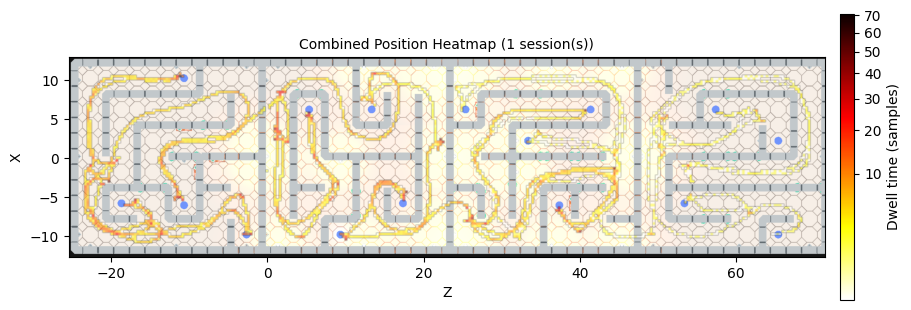

In [8]:
pos_dfs = [d['position'] for d in data.values() if not d['position'].empty]

if not pos_dfs:
    print('No position data.')
else:
    fig, ax = make_full_fig()
    draw_bg_full(ax)
    hm = make_heatmap_full(pos_dfs)
    cmap, norm = overlay_heatmap_full(ax, hm)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Dwell time (samples)', fraction=0.04, pad=0.02)
    ax.set_title(f'Combined Position Heatmap ({len(pos_dfs)} session(s))', fontsize=10)
    plt.savefig(DATA_DIR / 'heatmap_combined.png', dpi=150, bbox_inches='tight')
    plt.show()


## Minimap — Heatmap by Condition

Compare whether the active technique changes where participants spend time.

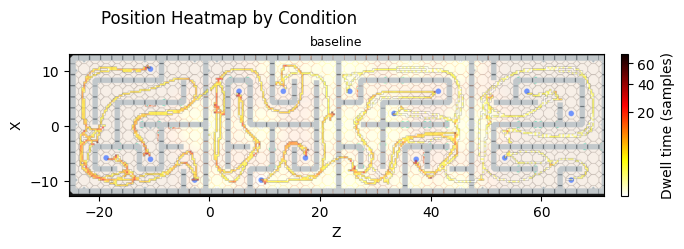

In [9]:
cond_pos: dict[str, list] = {}
for name, d in data.items():
    s = d['study']
    if s.empty or d['position'].empty:
        continue
    cond = s['condition'].dropna().iloc[0]
    cond_pos.setdefault(cond, []).append(d['position'])

if not cond_pos:
    print('No data.')
else:
    conditions = sorted(cond_pos)
    z_span = DISP_ZMAX - DISP_ZMIN
    x_span = DISP_XMAX - DISP_XMIN
    base_w = 9
    scale  = base_w / max(z_span, x_span)
    fw = max(z_span * scale, 3)
    # Height per subplot = width * (x_span / z_span) to honour equal aspect
    fh_per = fw * (x_span / z_span)

    fig, axes = plt.subplots(len(conditions), 1,
                             figsize=(fw, fh_per * len(conditions)),
                             layout='constrained', squeeze=False)

    cmap = norm = None
    for row, cond in enumerate(conditions):
        ax = axes[row, 0]
        draw_bg_full(ax)
        hm = make_heatmap_full(cond_pos[cond])
        cmap, norm = overlay_heatmap_full(ax, hm)
        ax.set_title(cond, fontsize=9)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes.ravel().tolist(), label='Dwell time (samples)', fraction=0.02, pad=0.02)
    fig.suptitle('Position Heatmap by Condition', fontsize=12)
    plt.savefig(DATA_DIR / 'heatmap_by_condition.png', dpi=150, bbox_inches='tight')
    plt.show()


## Minimap — Intrusion → Trigger Positions

Where intrusions occurred and where the technique fired. Arrows connect the two events for the same episode.

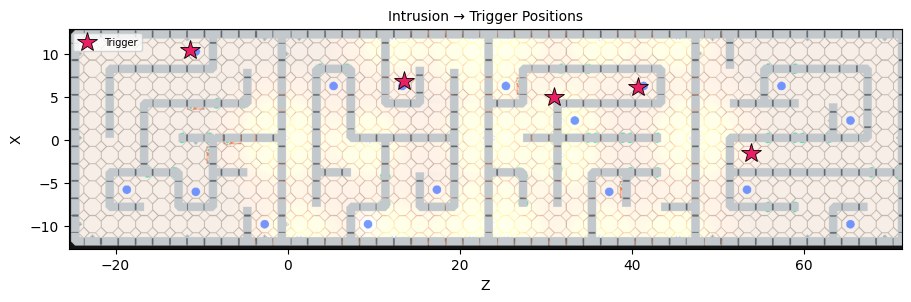

In [10]:
fig, ax = make_full_fig()
draw_bg_full(ax)
seen = set()

for name, d in data.items():
    s, pos = d['study'], d['position']
    if s.empty or pos.empty:
        continue

    for etype in ('INTRUSION_MARK', 'TRIGGER', 'FALSE_POSITIVE'):
        st = EVENT_STYLES[etype]
        for _, ev in s[s.event_type == etype].iterrows():
            px, pz = nearest_pos(pos, ev.timestamp_iso)
            if px is None:
                continue
            lbl = st['label'] if etype not in seen else '_nolegend_'
            seen.add(etype)
            ax.plot(pz, px, marker=st['marker'], color=st['color'],
                    markersize=st['ms'], zorder=st['zorder'],
                    markeredgecolor='black', markeredgewidth=0.6,
                    linestyle='None', label=lbl)

    intrusions = s[s.event_type == 'INTRUSION_MARK']
    triggers   = s[s.event_type == 'TRIGGER']
    for _, intr in intrusions.iterrows():
        later = triggers[triggers.timestamp_iso > intr.timestamp_iso]
        if later.empty:
            continue
        trig = later.iloc[0]
        ix, iz = nearest_pos(pos, intr.timestamp_iso)
        tx, tz = nearest_pos(pos, trig.timestamp_iso)
        if ix is not None:
            ax.annotate('', xy=(tz, tx), xytext=(iz, ix),
                        arrowprops=dict(arrowstyle='->', color='white', lw=1.5), zorder=7)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
              loc='upper left', fontsize=7)

ax.set_title('Intrusion → Trigger Positions', fontsize=10)
plt.savefig(DATA_DIR / 'minimap_intrusion_triggers.png', dpi=150, bbox_inches='tight')
plt.show()


## Minimap — Headset Gaze Direction

Arrows show where the participant was looking (XZ projection), sampled every N frames.

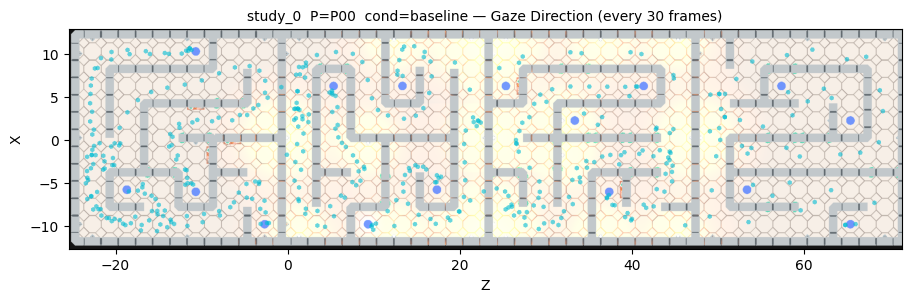

In [11]:
def quat_forward_xz(qx, qy, qz, qw):
    """Rotate Unity's forward vector (0,0,1) by quaternion; return (fx, fz)."""
    fx = 2*(qx*qz + qw*qy)
    fz = 2*(qy*qz - qw*qx)
    mag = np.sqrt(fx**2 + fz**2) + 1e-9
    return fx/mag, fz/mag

ARROW_STEP   = 30   # every Nth headset sample
ARROW_LENGTH = 0.4  # world units

with_head = [(n, d) for n, d in data.items() if not d['headset'].empty]
if not with_head:
    print('No headset data.')
else:
    for name, d in with_head:
        fig, ax = make_full_fig()
        draw_bg_full(ax)

        study = d['study']
        head  = d['headset'].iloc[::ARROW_STEP].copy()
        head['fx'], head['fz'] = zip(*head.apply(
            lambda r: quat_forward_xz(r.rot_x, r.rot_y, r.rot_z, r.rot_w), axis=1))

        # Axes are (Z horizontal, X vertical) — swap pos and direction components
        ax.quiver(
            head['pos_z'].values, head['pos_x'].values,
            head['fz'].values,    head['fx'].values,
            color='#00BCD4', alpha=0.6, scale=1/ARROW_LENGTH,
            scale_units='xy', angles='xy', width=0.006, zorder=3
        )

        pid  = study['participant_id'].dropna().iloc[0] if not study.empty else '?'
        cond = study['condition'].dropna().iloc[0]      if not study.empty else '?'
        ax.set_title(f'{name}  P={pid}  cond={cond} — Gaze Direction (every {ARROW_STEP} frames)',
                     fontsize=10)
        plt.savefig(DATA_DIR / 'minimap_headset_gaze.png', dpi=150, bbox_inches='tight')
        plt.show()


## Event Timeline

[timeline] Saved â†’ F:\Unity\Projects\DreamGuard\data\timeline.png



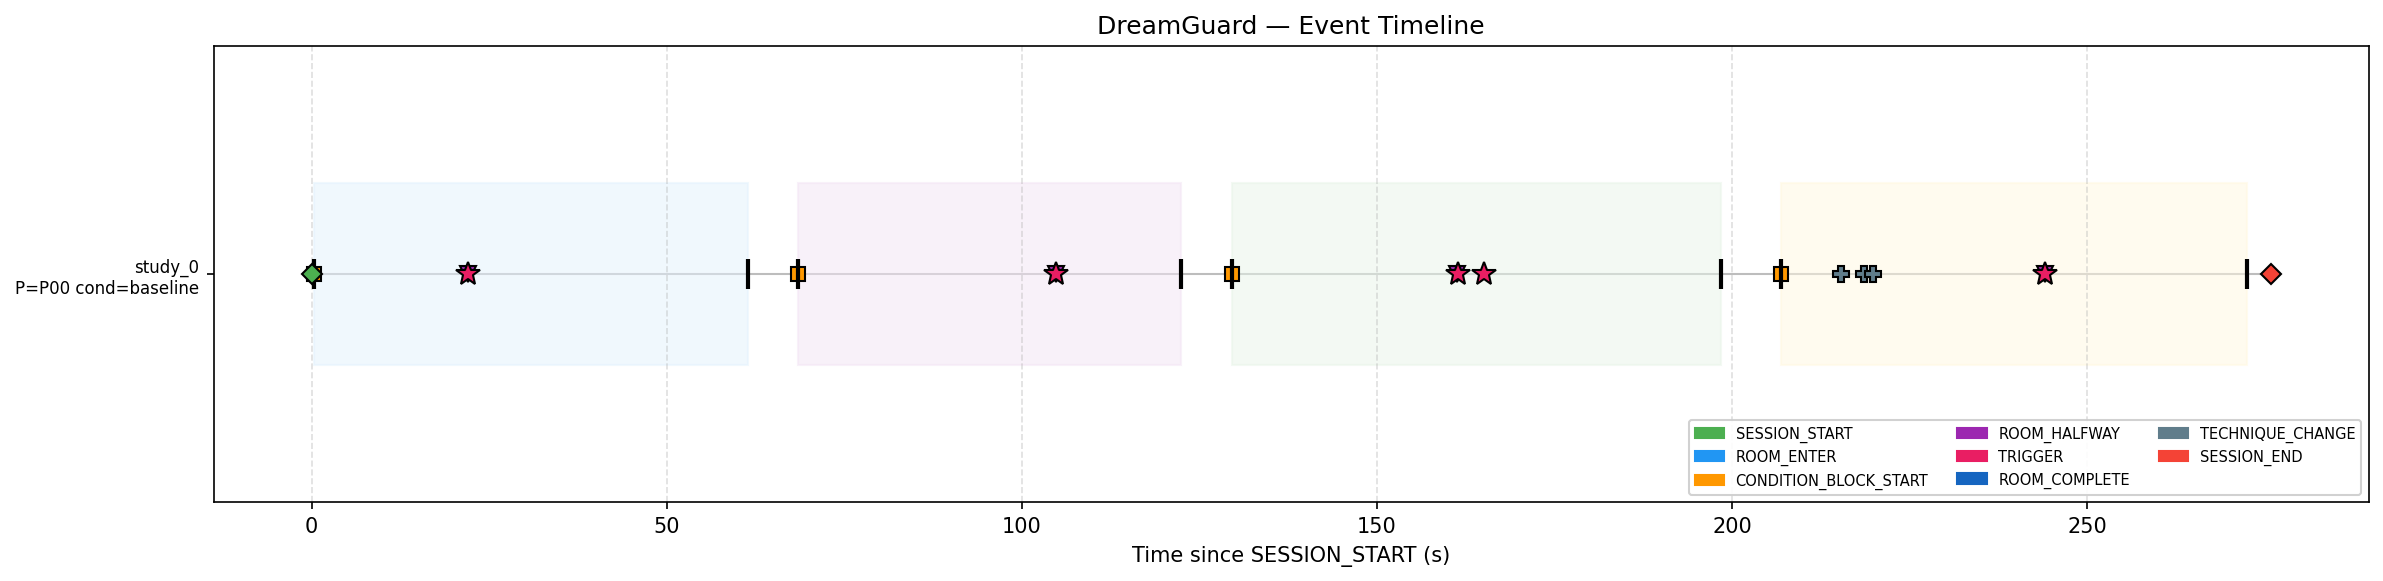

In [12]:
import subprocess, sys as _sys

timeline_out = DATA_DIR / 'timeline.png'
result = subprocess.run(
    ['uv', 'run', str(SCRIPTS_DIR / 'timeline.py'), str(DATA_DIR), '--out', str(timeline_out)],
    capture_output=True, text=True, cwd=str(SCRIPTS_DIR)
)
print(result.stdout)
if result.stderr:
    print(result.stderr, file=_sys.stderr)
if timeline_out.exists():
    display(IPyImage(str(timeline_out)))

## Export CSVs

In [13]:
for df, name in [
    (overview,   'summary.csv'),
    (latency_df, 'latency.csv') if not latency_df.empty else (None, None),
    (dur_df,     'room_durations.csv') if not dur_df.empty else (None, None),
]:
    if df is None:
        continue
    out = DATA_DIR / name
    df.to_csv(out, index=False)
    print(f'Saved → {out}')

Saved → F:\Unity\Projects\DreamGuard\data\summary.csv
Saved → F:\Unity\Projects\DreamGuard\data\latency.csv
Saved → F:\Unity\Projects\DreamGuard\data\room_durations.csv
